# **Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

# **Load the Dataset**

In [2]:
data = pd.read_csv("creditcard.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **Check Dataset Shape**

In [3]:
data.shape

(284807, 31)

# **Check Class Distribution**

In [4]:
data['Class'].value_counts()

,count
Class,
0,284315
1,492


# **Visualize Class Distribution**

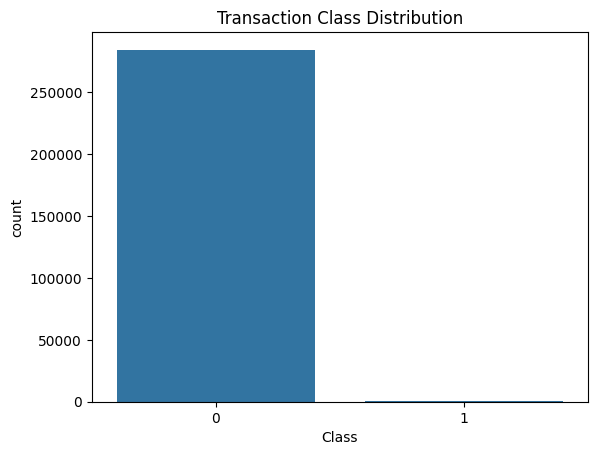

In [5]:
sns.countplot(x='Class', data=data)
plt.title("Transaction Class Distribution")
plt.show()

# **Feature Scaling**

In [6]:
scaler = StandardScaler()

data['Amount'] = scaler.fit_transform(data[['Amount']])

# **Separate Features and Labels**

In [7]:
X = data.drop('Class', axis=1)
y = data['Class']

# **Train Test Split**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# **Train Logistic Regression Model**

In [9]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

# **Make Predictions**

In [10]:
y_pred = lr_model.predict(X_test)

# **Evaluate the Model**

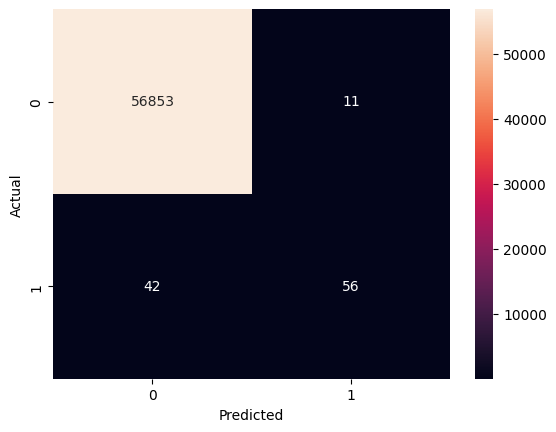

In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Classification Report**

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.57      0.68        98

    accuracy                           1.00     56962
   macro avg       0.92      0.79      0.84     56962
weighted avg       1.00      1.00      1.00     56962



# **Train Random Forest**

In [13]:
rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# **Evaluate Random Forest**

In [14]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.79      0.87        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



# **Calculate ROC-AUC Score**

In [15]:
roc_auc_score(y_test, rf_pred)

np.float64(0.892839557038347)

# **Predict Fraud Probability**

In [16]:
fraud_prob = rf_model.predict_proba(X_test)

fraud_prob[:5]

array([[0.01, 0.99],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ]])

# **Save the Model**

In [17]:
import joblib

joblib.dump(rf_model, "fraud_model.pkl")

['fraud_model.pkl']

In [20]:
model = joblib.load("fraud_model.pkl")

In [21]:
print(model)

RandomForestClassifier()


In [22]:
prediction = model.predict(X_test)

print(prediction[:10])

[1 0 0 0 0 0 0 0 0 0]


In [23]:
prob = model.predict_proba(X_test)

print(prob[:5])

[[0.01 0.99]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]]
